In [4]:
#change dir to the root of the repository before running this script
import os
if os.getcwd().split('/')[-1] != 'WIS_data_science_olmoearth_pretrain_2026':
    os.chdir('../../')

from WIS_DSP_lib.dataloader import Dataset, DataLoader
from WIS_DSP_lib.constants import *
import matplotlib.pyplot as plt
import numpy as np


In [5]:
# Load all data from the dataset
dataset = Dataset(h5py_dir=DATA_DIR)
data_loader = DataLoader(dataset=dataset, batch_size=6)

# take the sentinel2_l2a data - returns a numpy array of shape (batch_size, height, width, time, band)
pixel_data = next(iter(data_loader))[0]['sentinel2_l2a'].numpy()

In [25]:
print(f"Data Shape: {pixel_data.shape}")
print(f"Number of Samples (Batch): {pixel_data.shape[0]}")
print(f"Image Resolution: {pixel_data.shape[1]}x{pixel_data.shape[2]}")
print(f"Number of Timesteps: {pixel_data.shape[3]}")
print(f"Number of Spectral Bands: {pixel_data.shape[4]}")

Data Shape: (6, 64, 64, 11, 12)
Number of Samples (Batch): 6
Image Resolution: 64x64
Number of Timesteps: 11
Number of Spectral Bands: 12


## Assignment 
Generate a figure that explains this paragraph: 
> When all bandsets are encoded and decoded we find the task is too easy. Masked tokens in a bandset will likely have other tokens in the same bandset that are highly correlated with them that are visible in the input, tokens nearby spatially or temporally


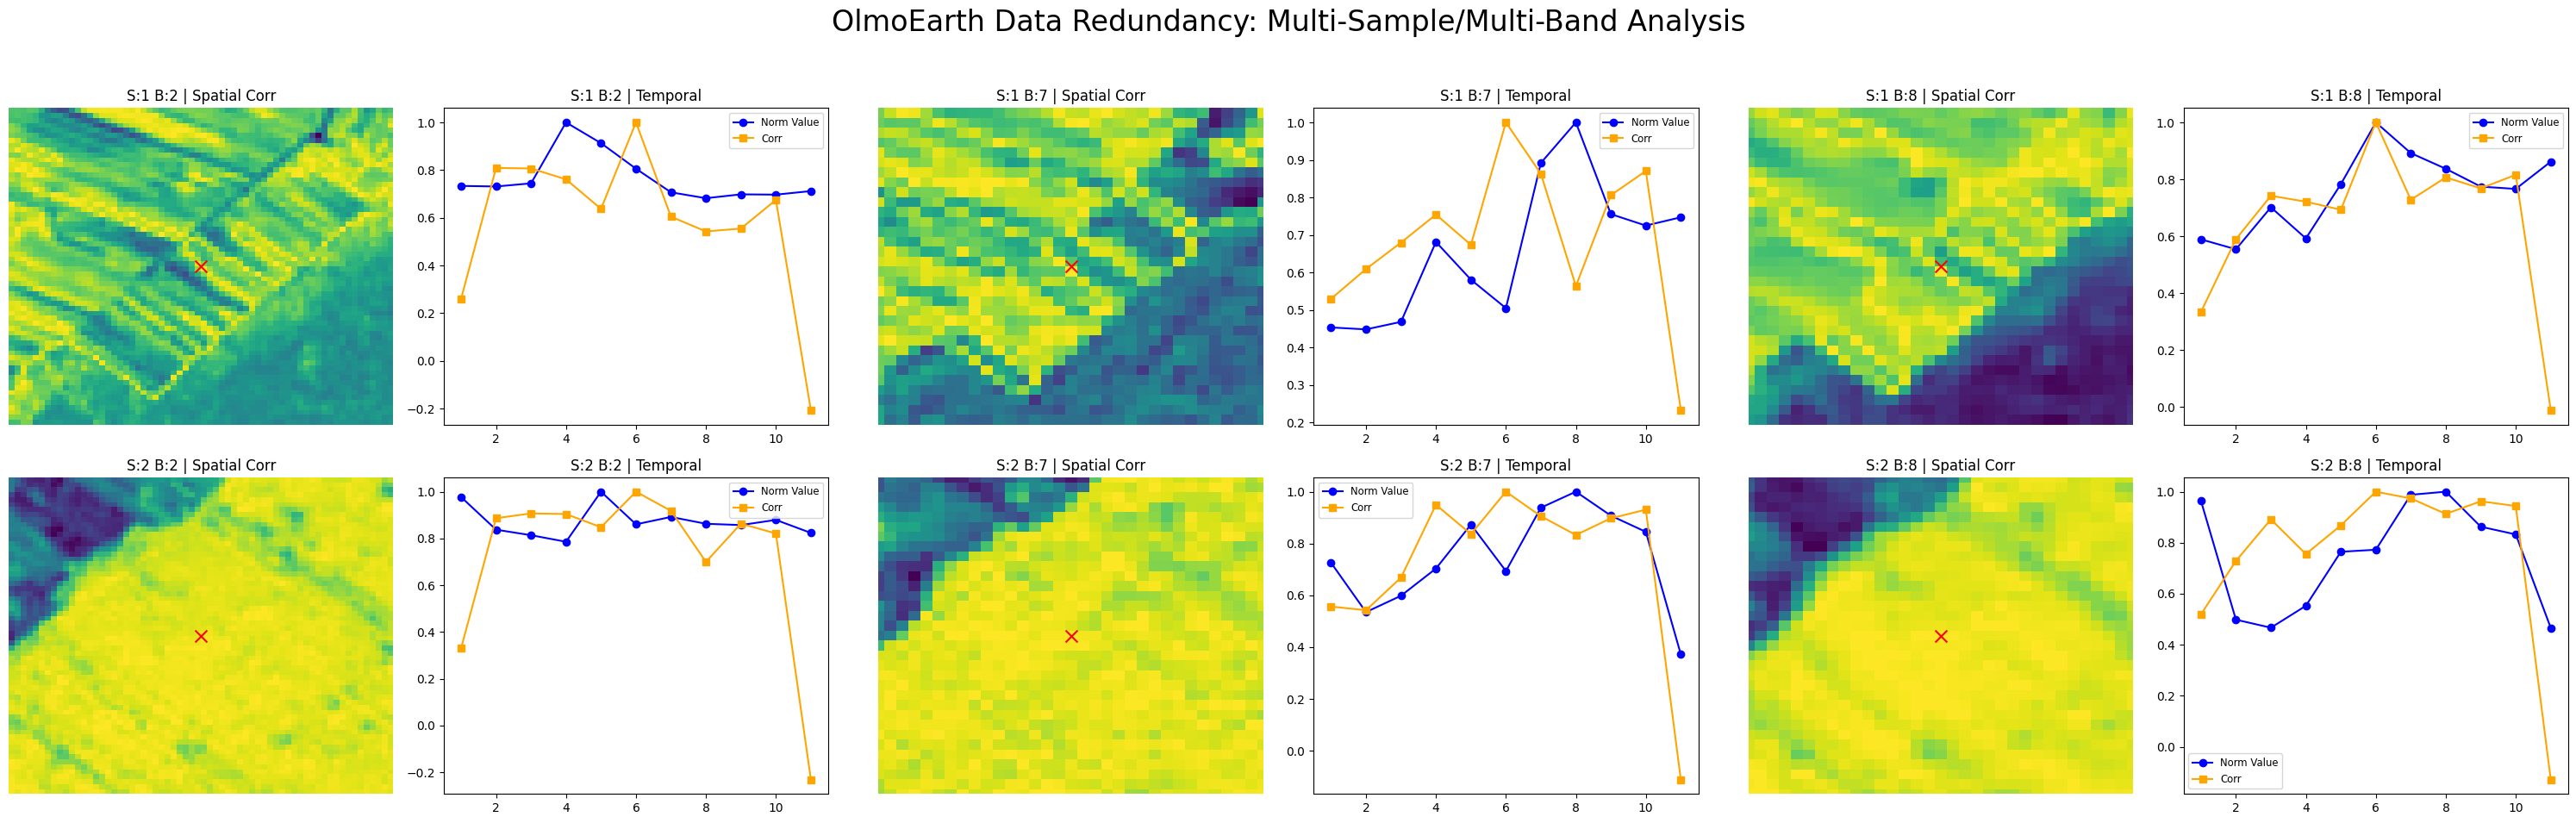

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select 2 batch indices and 3 band indices
num_batches, _, _, t_len, num_total_bands = pixel_data.shape
selected_batches = [1, 2] 
selected_bands = [2, 7, 8]

# 2. Setup a large figure with a grid of subplots
# Each row = a sample, Each column = a band
# Since each 'unit' has 2 plots (spatial/temporal), we use a 2x6 grid
fig, all_axes = plt.subplots(2, 6, figsize=(30, 10))

for r_idx, s_idx in enumerate(selected_batches):
    for c_idx, b_idx in enumerate(selected_bands):
        # Data Extraction
        single_band_data = pixel_data[s_idx, :, :, :, b_idx]
        h_mid, w_mid, t_mid = np.array(single_band_data.shape) // 2
        ref_value = single_band_data[h_mid, w_mid, t_mid]
        
        # Spatial Calculation
        spatial_slice = single_band_data[:, :, t_mid]
        spatial_corr = 1 - (np.abs(spatial_slice - ref_value) / (np.max(spatial_slice) + 1e-6))
        
        # Temporal Calculation
        flat_time = single_band_data.reshape(-1, t_len)
        temporal_profile = single_band_data[h_mid, w_mid, :]
        temporal_corr = np.corrcoef(flat_time, rowvar=False)[t_mid]
        
        # Mapping axes (each cell takes 2 subplots)
        ax_spatial = all_axes[r_idx, c_idx * 2]
        ax_temporal = all_axes[r_idx, c_idx * 2 + 1]
        
        # Plot Spatial
        sns.heatmap(spatial_corr, ax=ax_spatial, cmap='viridis', cbar=False)
        ax_spatial.scatter(w_mid, h_mid, color='red', marker='x', s=100)
        ax_spatial.set_title(f"S:{s_idx} B:{b_idx} | Spatial Corr")
        ax_spatial.axis('off')
        
        # Plot Temporal
        months = np.arange(1, t_len + 1)
        ax_temporal.plot(months, temporal_profile / (np.max(temporal_profile)+1e-6), 
                         marker='o', label='Norm Value', color='blue')
        ax_temporal.plot(months, temporal_corr, marker='s', label='Corr', color='orange')
        ax_temporal.set_title(f"S:{s_idx} B:{b_idx} | Temporal")
        if r_idx == 2: ax_temporal.set_xlabel("Month")
        ax_temporal.legend(fontsize='small')

plt.suptitle("OlmoEarth Data Redundancy: Multi-Sample/Multi-Band Analysis", fontsize=24)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('olmoearth_redundancy_grid.png')
plt.show()

In [43]:
print(spatial_slice.shape)
print(ref_value)
print(flat_time.shape)
print(temporal_profile.shape)

(64, 64)
0.18716726
(4096, 11)
(11,)
